In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
import pymannkendall as mk


In [10]:
def get_linregress_slope(arr):
    if (np.isnan(arr)).any():
        result = np.nan
    else:
        result = np.polyfit([i for i in range(len(arr))],arr,deg=1)[0]
        
    return(result)

def get_variance(arr):
    return(scipy.stats.variation(arr))

def get_mannkendall_slope(arr):
    if (np.isnan(arr)).any():
        result = np.nan
    else:
        result = mk.original_test(arr).slope
        
    return(result)
   
def get_mannkendall_p(arr):
    if (np.isnan(arr)).any():
        result = np.nan
    else:
        result = mk.original_test(arr).p
        
    return(result)


In [3]:
'''
plot FWI spatial mean ALL and NAT time series, dist
'''

in_path = '/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/6m_fire_season/'
out_path = '/nesi/project/niwa00015/queenle/plots/fire/ensemble_members/time_series/'

for ens_mem in range(1,102):

    print(ens_mem)
    if ens_mem == 100:
        number = 'm100'
    else:
        number = 'm00' + str(ens_mem) if ens_mem < 10 else 'm0' + str(ens_mem)
    if ens_mem == 101:
        number = 'ensMean'
        
    
    HPB_FWI_da = xr.open_dataarray(in_path+'FWI_HPB_'+number+'.nc')
    HPB_NAT_FWI_da = xr.open_dataarray(in_path+'FWI_HPB_NAT_'+number+'.nc')
    
    fig,axs = plt.subplots(1,2, figsize=(12,4),sharex=True)
    axs = axs.flatten()

    ALL_ts = HPB_FWI_da.mean(['latitude','longitude'])
    slope, inters = np.polyfit([i for i in range(len(ALL_ts))],ALL_ts,deg=1)
    axs[0].plot(ALL_ts.values, c='red', alpha=0.5, label = 'ALL')
    axs[0].plot([i for i in range(len(ALL_ts))], [slope*i +inters for i in range(len(ALL_ts))], c='red')
    axs[1].hist(HPB_FWI_da.values.flatten(), color= 'red', alpha=0.5, label = 'ALL')

    NAT_ts = HPB_NAT_FWI_da.mean(['latitude','longitude'])
    slope, inters = np.polyfit([i for i in range(len(NAT_ts))],NAT_ts,deg=1)
    axs[0].plot(NAT_ts.values, c='green', alpha=0.5, label = 'NAT')
    axs[0].plot([i for i in range(len(NAT_ts))], [slope*i +inters for i in range(len(NAT_ts))], c='green')
    axs[1].hist(HPB_NAT_FWI_da.values.flatten(), color= 'green', alpha=0.5, label = 'ALL')

    ax2 = axs[0].twinx()

    ANT_ts = ALL_ts - NAT_ts
    slope, inters = np.polyfit([i for i in range(len(ANT_ts))],ANT_ts,deg=1)
    #ax2.plot(ANT_ts.values, c='green', alpha=0.5)
    ax2.plot([i for i in range(len(ANT_ts))], [slope*i +inters for i in range(len(ANT_ts))], c='blue', label = 'ANT')
    ax2.set_ylim(-1,3)
    
    ax2.legend(loc='upper center')
    axs[0].legend(loc='upper left')
    axs[1].legend(loc='upper left')
    
    plt.savefig(out_path + 'FWI_' + number + '_timeseries.png')

    plt.close()


101


/home/queenle/.local/lib/python3.6/site-packages/numpy/lib/histograms.py:839: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/home/queenle/.local/lib/python3.6/site-packages/numpy/lib/histograms.py:840: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)
/home/queenle/.local/lib/python3.6/site-packages/numpy/lib/histograms.py:839: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/home/queenle/.local/lib/python3.6/site-packages/numpy/lib/histograms.py:840: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


In [67]:
test = xr.open_dataset('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/daily/inputs/HPB/FWI_inputs_HPB_m001_1951-2021.nc')

In [69]:
test.var

<bound method ImplementsDatasetReduce._reduce_method.<locals>.wrapped_func of <xarray.Dataset>
Dimensions:  (lat: 92, lev: 1, lon: 59, time: 25933)
Coordinates:
  * time     (time) datetime64[ns] 1951-01-01 1951-01-02 ... 2021-12-31
  * lon      (lon) float64 222.8 223.3 223.9 224.4 ... 253.7 254.2 254.8 255.4
  * lat      (lat) float64 19.94 20.5 21.06 21.62 ... 69.36 69.92 70.48 71.05
Dimensions without coordinates: lev
Data variables:
    precipi  (time, lev, lat, lon) float64 ...
    ta       (time, lev, lat, lon) float32 ...
    rha      (time, lev, lat, lon) float32 ...
    wind     (time, lev, lat, lon) float32 ...>

In [4]:
'''
plot FWI spatial mean ALL and NAT time series, dist
'''

def fire_season(month):
    return (month >= 5) & (month <= 10)

in_path = '/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/daily/inputs/'
out_path = '/nesi/project/niwa00015/queenle/plots/fire/inputs/ensemble_members/time_series/'

for ens_mem in range(1,102):
    
    if ens_mem < 101:
        continue
        
    print(ens_mem)
    if ens_mem == 100:
        number = 'm100'
    else:
        number = 'm00' + str(ens_mem) if ens_mem < 10 else 'm0' + str(ens_mem)
    if ens_mem == 101:
        number = 'ensMean'
        
    ALL_ds = xr.open_dataset(in_path+'HPB/FWI_inputs_HPB_'+number+'_1951-2021.nc')
    ALL_months_selected = ALL_ds.sel(time=fire_season(ALL_ds['time.month']))
    ALL_fire_season = ALL_months_selected.resample(time ='A').mean('time')
    
    NAT_ds = xr.open_dataset(in_path+'HPB_NAT/FWI_inputs_HPB_NAT_'+number+'_1951-2021.nc')
    NAT_months_selected = NAT_ds.sel(time=fire_season(NAT_ds['time.month']))
    NAT_fire_season = NAT_months_selected.resample(time ='A').mean('time')
    
    fig,axs = plt.subplots(2,2, figsize=(12,8),sharex=True)
    axs = axs.flatten()
    for i,var in enumerate(['ta','precipi','rha','wind']):
    
        ALL_ts = ALL_fire_season[var].mean(['lat','lon'])
        slope, inters = np.polyfit([i for i in range(len(ALL_ts))],ALL_ts,deg=1)
        axs[i].plot(ALL_ts.values, c='red', alpha=0.5, label = 'ALL')
        axs[i].plot([i for i in range(len(ALL_ts))], [slope*i +inters for i in range(len(ALL_ts))], c='red')

        NAT_ts = NAT_fire_season[var].mean(['lat','lon'])
        slope, inters = np.polyfit([i for i in range(len(NAT_ts))],NAT_ts,deg=1)
        axs[i].plot(NAT_ts.values, c='green', alpha=0.5, label = 'NAT')
        axs[i].plot([i for i in range(len(NAT_ts))], [slope*i +inters for i in range(len(NAT_ts))], c='green')

        ax2 = axs[i].twinx()

        ANT_ts = ALL_ts - NAT_ts
        slope, inters = np.polyfit([i for i in range(len(ANT_ts))],ANT_ts,deg=1)
        #ax2.plot(ANT_ts.values, c='blue', alpha=0.5, label = 'ANT')
        ax2.plot([i for i in range(len(ANT_ts))], [slope*i +inters for i in range(len(ANT_ts))], c='blue', label = 'ANT')
        ax2.set_ylim(-2,2)

        ax2.legend(loc='lower left')
        axs[i].legend(loc='upper left')
        axs[i].legend(loc='upper left')
        axs[i].set_title(var)
    
    plt.savefig(out_path + 'inputs_' + number + '_timeseries.png')
    plt.close()


101


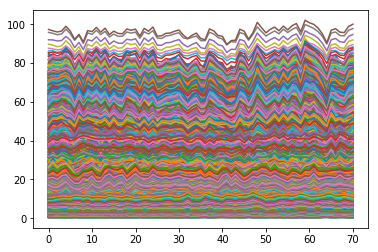

In [64]:
for lat in HPB_FWI_da.latitude:
    for lon in HPB_FWI_da.longitude:
        cell_ts = HPB_FWI_da.sel(latitude=lat,longitude=lon)
        plt.plot(cell_ts)

In [60]:
HPB_FWI_da.values.flatten()

array([       nan,        nan,        nan, ..., 1.60904172, 1.38886366,
       1.51486919])

In [56]:
'''
plot maps
'''

in_path = '/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/6m_fire_season/'
out_path = '/nesi/project/niwa00015/queenle/plots/fire/ensemble_members/maps/'
cmap = matplotlib.cm.get_cmap('viridis_r', 4)

for ens_mem in range(1,102):

    print(ens_mem)
    if ens_mem == 100:
        number = 'm100'
    else:
        number = 'm00' + str(ens_mem) if ens_mem < 10 else 'm0' + str(ens_mem)
    if ens_mem == 101:
        number = 'ensMean'
        
    fig,axs = plt.subplots(2,2, figsize=(12,10),sharex=True)
    axs = axs.flatten()
    
    all_da = xr.open_dataarray(in_path+'FWI_HPB_'+number+'.nc')
    nat_da = xr.open_dataarray(in_path+'FWI_HPB_NAT_'+number+'.nc')
    ant_da = all_da - nat_da

    xr.apply_ufunc(get_linregress_slope, all_da, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[0],vmin=-0.1,vmax=0.1,cmap='RdBu_r')
    xr.apply_ufunc(get_linregress_slope, nat_da, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[1],vmin=-0.1,vmax=0.1,cmap='RdBu_r')
    xr.apply_ufunc(get_linregress_slope, ant_da, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[2],vmin=-0.1,vmax=0.1,cmap='RdBu_r')
    im = xr.apply_ufunc(get_mannkendall_p, ant_da, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[3],vmin=0,vmax=0.4,cmap=cmap)#,norm=norm)

    axs[0].text(0.1,0.8,'ALL Trend',transform=axs[0].transAxes)
    axs[1].text(0.1,0.8,'NAT Trend',transform=axs[1].transAxes)
    axs[2].text(0.1,0.8,'ANT Trend',transform=axs[2].transAxes)
    axs[3].text(0.1,0.8,'ANT Trend p-values',transform=axs[3].transAxes)

    plt.savefig(out_path + 'FWI_' + number + '_maps.png')

    plt.close()

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101


In [5]:
'''
plot maps for inputs
'''

def fire_season(month):
    return (month >= 5) & (month <= 10)

in_path = '/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/daily/inputs/'
out_path = '/nesi/project/niwa00015/queenle/plots/fire/inputs/ensemble_members/maps/'
cmap = matplotlib.cm.get_cmap('viridis_r', 4)

range_dict = {'ta':[-0.03,0.03],
              'precipi':[-0.02,0.02],
              'wind':[-0.02,0.02],
              'rha':[-0.1,0.1]}

for ens_mem in range(1,102):
    
    if ens_mem < 101:
        continue
        
    print(ens_mem)
    if ens_mem == 100:
        number = 'm100'
    else:
        number = 'm00' + str(ens_mem) if ens_mem < 10 else 'm0' + str(ens_mem)
    if ens_mem == 101:
        number = 'ensMean'
        
    ALL_ds = xr.open_dataset(in_path+'HPB/FWI_inputs_HPB_'+number+'_1951-2021.nc')
    ALL_months_selected = ALL_ds.sel(time=fire_season(ALL_ds['time.month']))
    ALL_fire_season = ALL_months_selected.resample(time ='A').mean('time')
    
    NAT_ds = xr.open_dataset(in_path+'HPB_NAT/FWI_inputs_HPB_NAT_'+number+'_1951-2021.nc')
    NAT_months_selected = NAT_ds.sel(time=fire_season(NAT_ds['time.month']))
    NAT_fire_season = NAT_months_selected.resample(time ='A').mean('time')

    for var in ['ta','precipi','wind','rha']:

        fig,axs = plt.subplots(2,2, figsize=(12,10),sharex=True)
        axs = axs.flatten()
    
        all_da = ALL_fire_season[var]
        nat_da = NAT_fire_season[var]
        ant_da = all_da - nat_da

        xr.apply_ufunc(get_linregress_slope, all_da, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[0],vmin=range_dict[var][0],vmax=range_dict[var][1],cmap='RdBu_r')
        xr.apply_ufunc(get_linregress_slope, nat_da, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[1],vmin=range_dict[var][0],vmax=range_dict[var][1],cmap='RdBu_r')
        xr.apply_ufunc(get_linregress_slope, ant_da, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[2],vmin=range_dict[var][0],vmax=range_dict[var][1],cmap='RdBu_r')
        im = xr.apply_ufunc(get_mannkendall_p, ant_da, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[3],vmin=0,vmax=0.4,cmap=cmap)#,norm=norm)

        axs[0].text(0.1,0.8,'ALL Trend',transform=axs[0].transAxes)
        axs[1].text(0.1,0.8,'NAT Trend',transform=axs[1].transAxes)
        axs[2].text(0.1,0.8,'ANT Trend',transform=axs[2].transAxes)
        axs[3].text(0.1,0.8,'ANT Trend p-values',transform=axs[3].transAxes)

        plt.savefig(out_path + var + '/' + var + '_' + number + '_maps.png')
        plt.close()
        

101
